In [1]:
%matplotlib widget

In [2]:
import time

In [3]:
import torch.optim as optim
import torch

In [4]:
from chromatin3d.data.hic_loader import split
from chromatin3d.models.predictor import RousePINN
from chromatin3d.training.train import train
from chromatin3d.utils.misc import prettify_duration

In [5]:
train_loader, valid_loader = split("../data/ENCFF216QQM/ENCFF216QQM_chr1_5kbp/")

In [6]:
model = RousePINN(576)
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.load_state_dict(torch.load("model.pth", map_location=device))

<All keys matched successfully>

In [8]:
[i for i in model.parameters()]

[Parameter containing:
 tensor([[ 0.0291,  0.0294,  0.0287,  ...,  0.0316,  0.0287,  0.0284],
         [-0.0297, -0.0299, -0.0285,  ..., -0.0303,  0.0304, -0.0290],
         [-0.0286, -0.0305, -0.0295,  ..., -0.0306, -0.0293, -0.0312],
         ...,
         [ 0.0302,  0.0298,  0.0302,  ...,  0.0291,  0.0302,  0.0305],
         [ 0.0318,  0.0300,  0.0298,  ...,  0.0302,  0.0299,  0.0295],
         [ 0.0309,  0.0312,  0.0286,  ...,  0.0289,  0.0313,  0.0308]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0294, -0.0285, -0.0297, -0.0295,  0.0285,  0.0307,  0.0303, -0.0203,
         -0.0295, -0.0313,  0.0164,  0.0311,  0.0191,  0.0330, -0.0307, -0.0300,
          0.0291, -0.0300, -0.0299, -0.0315, -0.0299, -0.0315, -0.0308,  0.0283,
          0.0288,  0.0306,  0.0302, -0.0283,  0.0300,  0.0298, -0.0314,  0.0287,
         -0.0292,  0.0340,  0.0234, -0.0312, -0.0302, -0.0300,  0.0283,  0.0064,
         -0.0316, -0.0306, -0.0316,  0.0291,  0.0155, -0.0314, -0.0313,  0.0310

In [9]:
import torch
import matplotlib.pyplot as plt

In [10]:
for batch in train_loader:
    break

In [11]:
outputs = model(batch)

In [12]:
outputs.shape

torch.Size([10, 576, 3])

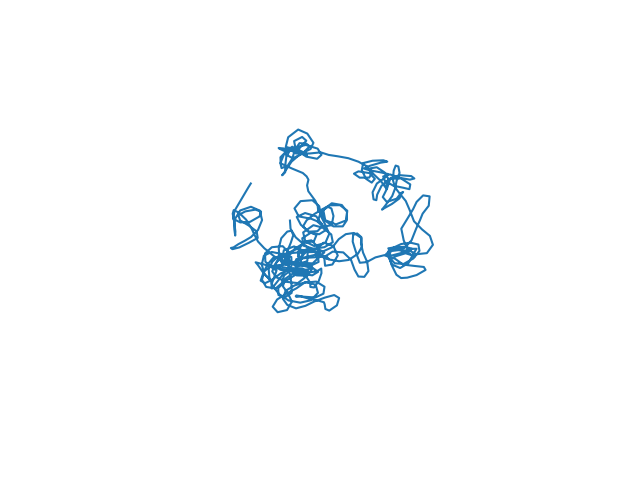

In [13]:
with torch.no_grad():
    fig = plt.figure()

    ax = fig.add_subplot(projection="3d")

    ax.plot(outputs[0, :, 0], outputs[0, :, 1], outputs[0, :, 2])

    ax.set_axis_off()

    plt.show()